# Comparing Integrators
This notebook goes through and compares the performance of the integrators currently built into the system

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import h5py
import scipy
from scipy.optimize import curve_fit

In [2]:
def readInOutputFile(outputFilename):
	optionsStructType = np.dtype([
		('B0', np.float64, 3),
		('E', np.float64, 3),
		('L', np.float64, 3),
		('yi', np.float64, 3),
		('posHistBins', np.float64, 3),
		('m', np.float64),
		('t0', np.float64),
		('tf', np.float64),
		('rtol', np.float64),
		('atol', np.float64),
		('beta', np.float64),
		('uround', np.float64),
		('safe', np.float64),
		('fac1', np.float64),
		('fac2', np.float64),
		('hmax', np.float64),
		('h', np.float64),
		('T', np.float64),
		('gamma', np.float64),
		('V', np.float64),
		('swapStepSize', np.float64),
		('ioutInt', np.float64),
		('nmax', np.uint32),
		('integratorType', np.int32),
		('numParticles', np.int32),
		('numPerGPUBlock', np.int32),
		('iout', np.int32),
		('numPhiBins', np.int32),
		('numThetaBins', np.int32),
		('dist', 'S', 1),
		('output', 'S', 1),
		('gas_coll', bool),
		('diffuse', bool),
		('gravity', bool),
		('pad', 'S', 7) #this is padding space just designed to fix the structure padding done in C++
	])
	file = open(outputFilename, 'rb')
	parameters = np.fromfile(file, count=1, dtype=optionsStructType)[0]
	data = None
	if parameters['output'] == b'n':
		#in this case it was the full dump of all particle data
		outputDtype = np.dtype([
			('t', '<f8'),
			('xx', '<f8'),
			('xy', '<f8'),
			('xz', '<f8'),
			('sx', '<f8'),
			('sy', '<f8'),
			('sz', '<f8')])
		file.seek(0, 0)
		data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
		numPer = int((parameters['tf']-parameters['t0'])/parameters['ioutInt'])+1
		data = data.reshape(numPer, parameters['numParticles']).T #this returns the data in a little more convenient format, I think
	elif parameters['output'] == b'h':
		#this is the histogram output format instead now
		numx = int(parameters['L'][0]/parameters['gridSize'])+1
		numy = int(parameters['L'][1]/parameters['gridSize'])+1
		numz = int(parameters['L'][2]/parameters['gridSize'])+1
		
		numVecBins = int(np.ceil(2.0/parameters['vecBinSize']))
		
		xbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
		ybins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize']) 
		zbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
		sbins = np.arange(-1.0, 1.0, parameters['vecBinSize'])
		outputDtype = np.dtype([
			('t', np.float64),
			('x', np.uint32, numx),
			('y', np.uint32, numy),
			('z', np.uint32, numz),
			('sx', np.uint32, numVecBins),
			('sy', np.uint32, numVecBins),
			('sz', np.uint32, numVecBins)
		])
		file.seek(0, 0)
		data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
		data = {'xbins': xbins,
			   'ybins': ybins,
			   'zbins': zbins,
			   'sbins': sbins,
			   'data': data}
	elif parameters['output'] == b'a':
		outputDtype = np.dtype([
			('t', np.float64),
			('sx', np.float64),
			('dsx', np.float64),
			('sy', np.float64),
			('dsy', np.float64),
			('sz', np.float64),
			('dsz', np.float64)
		])
		file.seek(0, 0)
		data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
	file.close()
	return parameters, data

def shiftDatapoints(phis):
    mean = np.mean(phis) #calculate the mean value
    shifted = np.copy(phis)
    #any values less than the mean by np.pi should be shifted up
    shifted[shifted<=(mean-np.pi)] += 2.0*np.pi
    shifted[shifted>=(mean+np.pi)] -= 2.0*np.pi
    std = np.std(shifted)
    shifted[shifted<(mean-np.pi/2)] = np.nan
    shifted[shifted>(mean+np.pi/2)] = np.nan
    return shifted

def analyzeDataset(dset, randomSample = False):
    times = np.sort(np.unique(dset[0]['t']))
    phis = np.arctan2(dset['sy'], dset['sz'])
    for i in range(len(times)):
        if randomSample:
            phis[:,i] = shiftDatapoints(np.random.choice(phis[:,i], size=phis[:,i].shape))
        else:
            phis[:,i] = shiftDatapoints(phis[:,i])
    means = np.nanmean(phis, axis=0)
    stds = np.nanstd(phis, axis=0)
    return times, means, stds

def bootstrapResults(dset, numBootstrap):
    times = []
    means = []
    stds = []
    for i in range(numBootstrap):
        print(i)
        time, mean, std = analyzeDataset(dset, randomSample=True)
        times.append(time)
        means.append(mean)
        stds.append(std)
    times = times[0]
    means = np.array(means)
    stds = np.array(stds)
    return times, means, stds

## Load in the RK45 Dataset

In [3]:
#load in the no electric field dataset

directory = '/storage/home/hcoda1/9/dmathews33/scratch/noEField/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parametersRK45Quat = []
datasetRK45Quat = []
for f in original:
    temp = readInOutputFile(f)
    parametersRK45Quat.append(temp[0])
    datasetRK45Quat.append(temp[1])
parametersRK45Quat = np.array(parametersRK45Quat)
datasetRK45Quat = np.concatenate(np.array(datasetRK45Quat), axis=0)

18296


## Load in the DOP853 Dataset

In [5]:
#load in the no electric field dataset

directory = '/storage/home/hcoda1/9/dmathews33/scratch/noEField/DOP853Integrator/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parametersDOP853 = []
datasetDOP853 = []
for f in original:
    temp = readInOutputFile(f)
    parametersDOP853.append(temp[0])
    datasetDOP853.append(temp[1])
parametersDOP853 = np.array(parametersDOP853)
datasetDOP853 = np.concatenate(np.array(datasetDOP853), axis=0)

19480


## Start the Comparisons

In [11]:
resultsDOP853 = analyzeDataset(datasetDOP853)
resultsRK45Quat = analyzeDataset(datasetRK45Quat)

In [15]:
times = np.copy(resultsDOP853[0])

w = parametersDOP853[0]['gamma']*np.sqrt(np.sum(np.square(parametersDOP853[0]['B0']))) #calculate the frequency
period = abs(2.0*np.pi/w) #calculate the period of the oscillation
locationInPeriod = (times/period)%1
trueAngle = locationInPeriod*2.0*np.pi

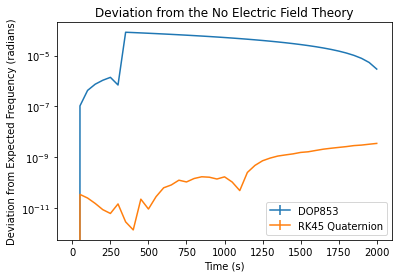

In [22]:
deviationsDOP853 = np.copy(resultsDOP853[1])
deviationsDOP853[deviationsDOP853<0] += np.pi*2.0
deviationsDOP853[deviationsDOP853>0] = 2.0*np.pi - deviationsDOP853[deviationsDOP853>0]
deviationsDOP853 = np.subtract(deviationsDOP853, trueAngle[None,])[:]
numPartsDOP853 = deviationsDOP853.shape[0]

deviationsRK45Quat = np.copy(resultsRK45Quat[1])
deviationsRK45Quat[deviationsRK45Quat<0] += np.pi*2.0
deviationsRK45Quat[deviationsRK45Quat>0] = 2.0*np.pi - deviationsRK45Quat[deviationsRK45Quat>0]
deviationsRK45Quat = np.subtract(deviationsRK45Quat, trueAngle[None,])[:]
numPartsRK45Quat = deviationsRK45Quat.shape[0]

plt.errorbar(times, abs(np.nanmean(deviationsDOP853, axis=0)), yerr=np.nanstd(deviationsDOP853, axis=0)/np.sqrt(numPartsDOP853), label='DOP853')
plt.errorbar(times, abs(np.nanmean(deviationsRK45Quat, axis=0)), yerr=np.nanstd(deviationsRK45Quat, axis=0)/np.sqrt(numPartsRK45Quat), label='RK45 Quaternion')
plt.xlabel('Time (s)')
plt.ylabel('Deviation from Expected Frequency (radians)')
plt.title('Deviation from the No Electric Field Theory')
plt.legend()
plt.yscale('log')
plt.show()